# AP 155 Lab Exercise
---
## Exercise 1: Idiomatic Python

_Instructions_: 
- **Report figure (Problem 1):** Plot the 2D wave interference pattern between 2 (or more) coherent sources. Include at least 1 figure.
- **Report discussion (Problem 2):** Write a custom `matrix_multiply()`function using Python list comprehensions without external libraries (do not use `np.dot()` or `@`).
    - (i) For larger matrices, which is preferred, the custom `matrix_multiply()` or the `@` operator... why?
    - (ii) What are the general benefits of writing idiomatic Python?
- **Code**: Complete the codes and ensure they are functional, error-free, readable, and efficient (where needed). Include a concise markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Rivera, Kyle Florian
- _Student No._: 2024-161997
- _Section_: THU-TX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1G9tPPcyMUag91g_R02O0wsGYPiZWy5Nn/view?usp=drive_link) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Problem 1: 2D Wave interference (Gezerlis Problem 1.15)

![Figure for the Interference plot of Problem 1](./Figures/Interference.png)

Figure 1: 2D wave interference pattern of 4 objects located at $(\pm 1,0)$ and $(0, \pm 1)$. All spatial coordinates and values are given in arbitrary units (a.u.).

The figure shows the density plot of the field $W(r)$, showing interference from four point sources. Darker shades indicate constructive interference and a higher wave amplitude, while lighter regions show destructive interference. Notably, a constructive interference can be seen in the origin, which is equidistant from all four point sources, as noted by its darker shading.

### Problem 2: Listcomps-maxxing

A custom algorithm for computing the product of two matrices was created from scratch, without the use of external libraries such as NumPy. The output matrix was obtained by iteratively evaluating the scalar product between the rows of the left matrix and the columns of the right matrix.

1. For larger matrices, which is preferred, the custom `matrix_multiply()` or the `@` operator... why?
    - The `@` operator is preferred as it utilizes Python's unique features (a.k.a. Idiomatic Python) in order to efficiently compute the product of two matrices. The custom algorithm I have designed haven't fully utilized Python's features, as evident by the use of for loops in some parts, particularly in generating the random matrice.
2. What are the general benefits of writing idiomatic Python?
    - In general, writing idiomatic Python significantly improves readability and code clarity, making it easier to debug and understand. Moreover, coding idiomatically (e.g. using built-in functions) allows the code to run faster and use comparatively less resources, as Python optimally executes these operations.

### Other comments
- Although I know that for loops are slower than list comprehension, I tend to use it first when implementing as I find it easier to comprehend.

---
## Section 2: Code

### Problem 1: 2D Wave interference (Gezerlis Problem 1.15)

Assume that the combined eﬀect of two objects dropped in a water basin can be modelled by:
$$ W(\textbf{r}) = A \sin (k|\textbf{r}-\textbf{r}_0|) + A  \sin (k|\textbf{r}-\textbf{r}_1|). $$ You can think of this as an updated version of Eq. (1.3) in the book, where we are dealing with the linear addition of sinusoidal waves, instead of electric-field contributions. For simplicity, take $A=1$, $k=2\pi/0.3$, $r_0 = (−1, 0)$ , and $r_1 = (1, 0)$. Since we are now faced with a density plot, you should employ, NOT `streamplot()` but, `imshow()` from `Matplotlib`; in each of $x$ and $y$ your plot should extend from $−4$ to $+4$.

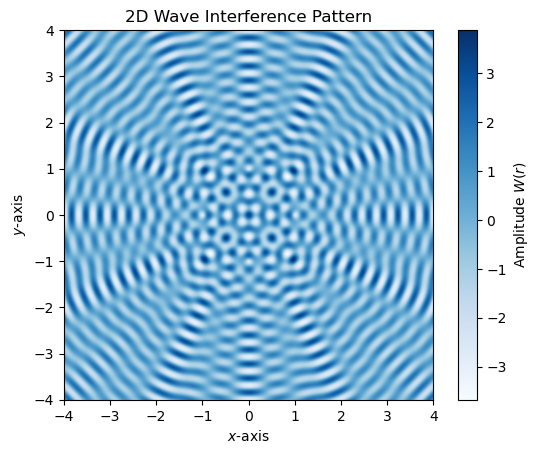

In [1]:
# %%timeit
import matplotlib.pyplot as plt
import math as m

# -- constants --
A = 1 
k = (2*m.pi/0.3)

# -- modelling the water basin --
def W(xs, ys):
    r = [(-1, 0), (1, 0), (0, 1), (0, -1)] # r_i: where the objects are dropped
    n = len(xs)
    Ws = [[0. for i in range(n)] for j in range(n)] # generates a zero n x n matrix. this is where we put W(r)
    # going through all the elements of the matrix
    for i,x in enumerate(xs):
        for j,y in enumerate(ys):
            for rx, ry in r: # we iterate over all objects
                R = m.sqrt((x - rx)**2 + (y - ry)**2) 
                Ws[j][i] += A * m.sin(k*R) # we put the values in their respective positions in the matrix.
    return Ws

def plotfield(box, n):
    # generates an array of x & y-pts to compute W(r), with centre at the origin
    xs = [-box + i*2*box/(n-1) for i in range(n)] 
    ys = xs[:] 
    Ws = W(xs,ys) 
    
    plt.title('2D Wave Interference Pattern')
    plt.imshow(Ws, extent=(-box, box, -box, box), cmap='Blues') # (box,box...) boundaries of plot
    plt.colorbar(label='Amplitude $W(r)$')
    plt.xlabel('$x$-axis')
    plt.ylabel('$y$-axis')
    plt.savefig("Figures/Interference.png")
    plt.show()
    
fig = plotfield(4, 1000) # we not plot it

#### Problem 1 code summary

Include a brief summary (2–3 sentences) at the bottom of your code outlining the purpose of the script and its core algorithm. Focus on explaining why you wrote the code this way and the reasoning behind your implementation choices.

- The following code is used in order to generate a density plot of a scalar function and visualize 2D wave interference. The influence of each object dropped in a basin is calculated iteratively over every spatial coordinate within the bounds of the graph. A nested for loop was used as it easily visualizes the step-by-step process of calculating the values at each coordinate.

---

### Problem 2: Listcomps-maxxing

Import the `random` library (docs: https://docs.python.org/3/library/random.html). We will be using the `random.randint` function to pick random integers.

In [2]:
import random
number = random.randint(1, 9)
number

2

a. Create a function `random_integer_matrix(nrows, ncols)` that generates a matrix in the form of "list-of-lists" whose elements are random integers from $1$ to $9$. Each "sub-list" inside the main list is a row in the matrix.

In [3]:
def random_integer_matrix(nrows, ncols):
    M = [[0 for x in range(ncols)] for y in range(nrows)] # generate an i by j zero matrix. acts as placeholder again
    for i in range(nrows):
        for j in range(ncols):
            M[i][j] = random.randint(1, 9)
    return M

list_1 = random_integer_matrix(3, 4) # call the function to create a 3x4 matrix
list_2 = random_integer_matrix(3, 4)
print(list_1, ",\n", list_2)

[[8, 6, 1, 5], [8, 1, 9, 5], [9, 9, 6, 3]] ,
 [[8, 7, 5, 4], [4, 5, 3, 2], [3, 8, 4, 3]]


b. Create a function `scalar_product(list1, list2)` where you multiply each element at the same index in the two lists and sum/accumulate the results.

In [4]:
# we generate a random vector of n-dimension
def random_vector(n):
    V = [0 for x in range(n)]
    for i  in range(n):
        V[i] = random.randint(1,9)
    return V
    
vec_1 = random_vector(4)
vec_2 = random_vector(4)
print(vec_1, ",\n", vec_2)

def check_dimensions(list_1, list_2):
    # edge cases, ensures that both vectors are of the same dimension
    if len(list_1) != len(list_2):
        print("Invalid input. Different dimensions")
        return False
    return True
    
def scalar_product(list_1, list_2):
    if check_dimensions(list_1, list_2): # we check if both vectors are in the same dimension
        product = 0 
        for i in range(len(list_1)): # iterates through the entire list
            product += list_1[i] * list_2[i]
    return product

print(f"Scalar Product: {scalar_product(vec_1, vec_2)}")

[1, 4, 3, 2] ,
 [4, 1, 7, 8]
Scalar Product: 45


c. Create a function `transpose_matrix(orig_matrix)` which returns the transpose of any matrix also in "list-of-lists" form. Do not assume the size of the matrix; figure it out within the function. Double-check that your implementations above work. Create a $3\times4$ random integer matrix, print it out and its transpose. The values and shape between the two should be consistent.

In [5]:
matrix = random_integer_matrix(2, 3)
print(matrix)

def transpose_matrix(orig_matrix):
    nrows, ncols = len(orig_matrix), len(orig_matrix[0])
    transposed_matrix = [[0 for x in range(nrows)] for y in range(ncols)] # we create a placeholder matrix with rows ncols and columns of nrows
    # note: this part is only necessary when using for loops
    for i in range(nrows):
        for j in range(ncols):
            transposed_matrix[j][i] = orig_matrix[i][j] # we simply swap indices similar to how a transpose operation works
    return transposed_matrix
    
transpose_matrix(matrix)

[[2, 5, 9], [7, 5, 3]]


[[2, 7], [5, 5], [9, 3]]

Alternatively, we can use list comprehension instead

In [6]:
matrix = random_integer_matrix(2, 3)
print(matrix)

def transpose_matrix(orig_matrix):
    nrows, ncols = len(orig_matrix), len(orig_matrix[0])
    transposed_matrix = [[orig_matrix[i][j] for i in range(nrows)] for j in range(ncols)]
    # alternatively, we can define it using list comprehension
    return transposed_matrix
    
transpose_matrix(matrix)

[[5, 5, 4], [4, 5, 7]]


[[5, 4], [5, 5], [4, 7]]

d. Create a function `matrix_multiply(left_matrix, right_matrix)` which performs the matrix multiplication. Do not assume the matrices follow a specific shape. Here's some tips and strategies:
* Determine how many rows and columns the left and right matrices have. Which numbers should match in order for us to have valid matrix multiplication?
* Iterating the elements of "list-of-lists" gives us the rows, but we need to iterate the columns for the right matrix.
* Use the `transpose_matrix` function, then iteratively apply `scalar_product`.

In [7]:
import numpy as np

matrix_1 = random_integer_matrix(2, 3)
matrix_2 = random_integer_matrix(3, 2)
print(f"Matrix A: {matrix_1} \nMatrix B: {matrix_2}")

def matrix_multiply(A, B):
    if len(A[0]) != len(B): # we check if the multiplication is valid, i.e. if the number of columns in matrix A is equal to the number of rows in matrix B
        print("Product not defined. Invalid dimensions.")
        return        
    prod_rows = len(A)
    prod_columns = len(B[0])
    transposed_B = transpose_matrix(B) # we transpose the matrix B so we can utilize the scalar_product function in order to easily compute the product
    product = [[scalar_product(A[y], transposed_B[x]) for x in range(prod_columns)] for y in range(prod_rows)] # we iterate throughout the elements of the matrix product

    return product

print(f"matrix_multiply_func: {matrix_multiply(matrix_1, matrix_2)}") 
print(f"matrix_multiply_with@: {np.array(matrix_1) @ np.array(matrix_2)}") # as a sanity check, we compare with the built-in operation 

Matrix A: [[3, 7, 6], [7, 2, 6]] 
Matrix B: [[1, 3], [8, 8], [8, 4]]
matrix_multiply_func: [[107, 89], [71, 61]]
matrix_multiply_with@: [[107  89]
 [ 71  61]]


#### Problem 2 code summary

Include a brief summary (2–3 sentences) at the bottom of your code outlining the purpose of the script and its core algorithm. Focus on explaining why you wrote the code this way and the reasoning behind your implementation choices.

- A basic matrix multiplication algorithm was implemented without using NumPy. For operations computed using explicit loops, variables are first initialized as zero-filled placeholders before the scalar product, transposition, and matrix multiplication are calculated element-by-element. This is done as it was the most intuitive way (for me) of doing it from scratch.